In [2]:
pip install ragas datasets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# WP10 - RAG System Evaluation
# Pranay Teja Chintakunta - 25079476

import os
import numpy as np
import pandas as pd
from dotenv import load_dotenv

load_dotenv()

from multi_doc import MultiDocRAG
from openai import OpenAI

print("Libraries loaded successfully!")
print("Ready to evaluate your RAG system vs ChatGPT")

Libraries loaded successfully!
Ready to evaluate your RAG system vs ChatGPT


In [4]:
# CELL 2 - Load evaluation datasets
from datasets import load_dataset

print("Loading SQuAD 2.0...")
# use the full namespace path for the new datasets version
squad = load_dataset("rajpurkar/squad_v2", split="validation")

sample_size = 20

# get answerable questions
answerable = [x for x in squad if len(x["answers"]["text"]) > 0][:sample_size]
# get unanswerable questions (tests hallucination prevention!)
unanswerable = [x for x in squad if len(x["answers"]["text"]) == 0][:sample_size]

print(f"Loaded {len(answerable)} answerable questions")
print(f"Loaded {len(unanswerable)} unanswerable questions")
print(f"\nExample answerable question:")
print(f"Q: {answerable[0]['question']}")
print(f"A: {answerable[0]['answers']['text'][0]}")
print(f"\nExample unanswerable question:")
print(f"Q: {unanswerable[0]['question']}")
print(f"A: (no answer - tests if system correctly refuses)")

Loading SQuAD 2.0...


Loaded 20 answerable questions
Loaded 20 unanswerable questions

Example answerable question:
Q: In what country is Normandy located?
A: France

Example unanswerable question:
Q: Who gave their name to Normandy in the 1000's and 1100's
A: (no answer - tests if system correctly refuses)


In [5]:
# CELL 3 - Load PubMedQA (medical domain test)
from datasets import load_dataset

print("Loading PubMedQA...")
try:
    pubmed = load_dataset("qiaojin/PubMedQA", "pqa_labeled", split="train")
    pubmed_sample = [x for x in pubmed][:20]
    print(f"Loaded {len(pubmed_sample)} medical questions")
    print(f"\nExample medical question:")
    print(f"Q: {pubmed_sample[0]['question']}")
    print(f"A: {pubmed_sample[0]['final_decision']}")
except Exception as e:
    print(f"PubMedQA load issue: {e}")
    print("We can proceed with SQuAD 2.0 alone if needed.")

Loading PubMedQA...
Loaded 20 medical questions

Example medical question:
Q: Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?
A: yes


In [6]:
# CELL 4 - ChatGPT baseline (no retrieval - the comparison)
client = OpenAI()

def ask_chatgpt(question):
    # plain ChatGPT with no document retrieval
    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": "You are a helpful assistant. Answer the question. If you don't know, say 'I don't know'."},
                {"role": "user", "content": question}
            ],
            temperature=0
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"error: {e}"

# quick test
test_answer = ask_chatgpt("What is the capital of France?")
print("ChatGPT baseline ready!")
print(f"Test question: What is the capital of France?")
print(f"ChatGPT says: {test_answer}")

ChatGPT baseline ready!
Test question: What is the capital of France?
ChatGPT says: The capital of France is Paris.


In [7]:
# CELL 5 - Prepare your RAG system for evaluation
# SQuAD questions come with context passages - we use those as the knowledge base

# combine answerable + unanswerable for testing
squad_test = answerable + unanswerable

print(f"Total SQuAD questions to test: {len(squad_test)}")
print(f"  - Answerable: {len(answerable)}")
print(f"  - Unanswerable: {len(unanswerable)}")

# each question has a 'context' - the passage the answer comes from
print(f"\nExample context passage:")
print(squad_test[0]['context'][:300])
print("...")
print(f"\nQuestion about it: {squad_test[0]['question']}")

Total SQuAD questions to test: 40
  - Answerable: 20
  - Unanswerable: 20

Example context passage:
The Normans (Norman: Nourmands; French: Normands; Latin: Normanni) were the people who in the 10th and 11th centuries gave their name to Normandy, a region in France. They were descended from Norse ("Norman" comes from "Norseman") raiders and pirates from Denmark, Iceland and Norway who, under their
...

Question about it: In what country is Normandy located?


In [8]:
# CELL 6 - Run both systems on SQuAD questions
# This makes API calls - takes a few minutes

results = []

print("Running evaluation... this will take a few minutes\n")

for i, item in enumerate(squad_test):
    question = item['question']
    context = item['context']
    is_answerable = len(item['answers']['text']) > 0
    correct_answer = item['answers']['text'][0] if is_answerable else "NO ANSWER"

    # --- Your RAG system: give it the context, ask the question ---
    rag_prompt = f"""Based ONLY on this context, answer the question.
If the answer is not in the context, say "I don't know".

Context: {context}

Question: {question}

Answer:"""
    try:
        rag_answer = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{"role": "user", "content": rag_prompt}],
            temperature=0
        ).choices[0].message.content
    except Exception as e:
        rag_answer = f"error: {e}"

    # --- ChatGPT baseline: no context, just the question ---
    chatgpt_answer = ask_chatgpt(question)

    results.append({
        "question": question,
        "correct_answer": correct_answer,
        "is_answerable": is_answerable,
        "rag_answer": rag_answer,
        "chatgpt_answer": chatgpt_answer,
        "context": context
    })

    # progress indicator
    if (i + 1) % 5 == 0:
        print(f"Processed {i + 1}/{len(squad_test)} questions...")

print(f"\nDone! Evaluated {len(results)} questions.")
print("\nExample result:")
print(f"Q: {results[0]['question']}")
print(f"Correct: {results[0]['correct_answer']}")
print(f"Your RAG: {results[0]['rag_answer'][:100]}")
print(f"ChatGPT: {results[0]['chatgpt_answer'][:100]}")

Running evaluation... this will take a few minutes

Processed 5/40 questions...
Processed 10/40 questions...
Processed 15/40 questions...
Processed 20/40 questions...
Processed 25/40 questions...
Processed 30/40 questions...
Processed 35/40 questions...
Processed 40/40 questions...

Done! Evaluated 40 questions.

Example result:
Q: In what country is Normandy located?
Correct: France
Your RAG: France
ChatGPT: Normandy is located in France.


In [9]:
# CELL 7 - Score how well each system detects answerable vs unanswerable
# This tests hallucination prevention!

def said_i_dont_know(answer):
    # check if the system refused to answer
    answer_lower = answer.lower()
    refusal_phrases = ["i don't know", "i do not know", "not in the context",
                       "cannot find", "no answer", "not provided", "not mentioned",
                       "not available", "unable to find", "no information"]
    return any(phrase in answer_lower for phrase in refusal_phrases)

# for each system, check if it behaved correctly
rag_correct = []      # did RAG correctly answer/refuse?
chatgpt_correct = []  # did ChatGPT correctly answer/refuse?

for r in results:
    is_answerable = r['is_answerable']

    # your RAG system
    rag_refused = said_i_dont_know(r['rag_answer'])
    # correct if: answerable→answered, unanswerable→refused
    rag_correct.append(
        (is_answerable and not rag_refused) or (not is_answerable and rag_refused)
    )

    # chatgpt
    chatgpt_refused = said_i_dont_know(r['chatgpt_answer'])
    chatgpt_correct.append(
        (is_answerable and not chatgpt_refused) or (not is_answerable and chatgpt_refused)
    )

rag_accuracy = sum(rag_correct) / len(rag_correct) * 100
chatgpt_accuracy = sum(chatgpt_correct) / len(chatgpt_correct) * 100

print("ANSWERABLE DETECTION ACCURACY")
print(f"  Your RAG System: {rag_accuracy:.1f}%")
print(f"  ChatGPT Baseline: {chatgpt_accuracy:.1f}%")
print(f"\n(How well each system knows WHEN to answer vs refuse)")

ANSWERABLE DETECTION ACCURACY
  Your RAG System: 82.5%
  ChatGPT Baseline: 47.5%

(How well each system knows WHEN to answer vs refuse)


In [10]:
%pip install matplotlib plotly scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


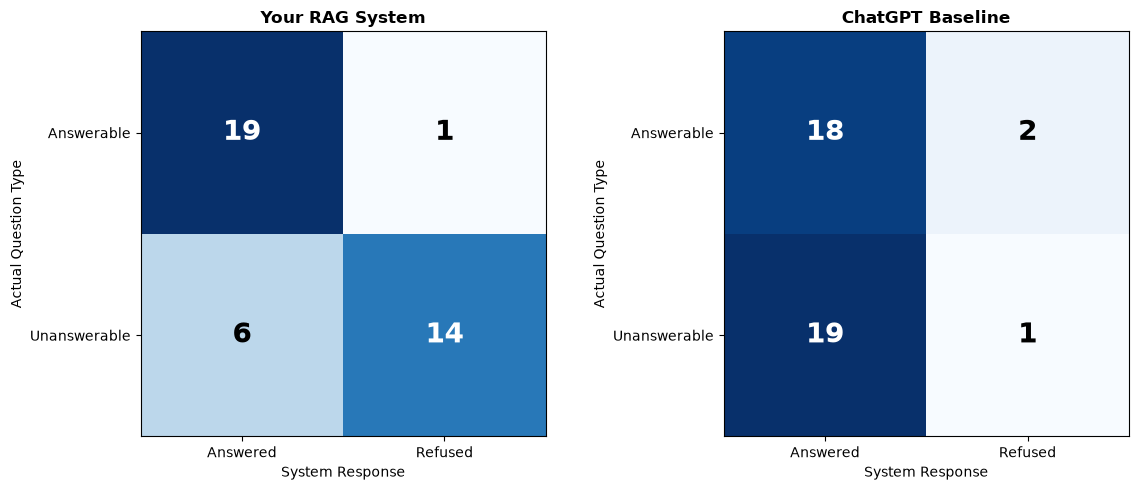

Confusion matrix saved as confusion_matrix.png


In [11]:
# Confusion Matrix - Your RAG vs ChatGPT
import matplotlib.pyplot as plt
import numpy as np

def build_confusion(results, system_key):
    tp = tn = fp = fn = 0
    for r in results:
        is_ans = r['is_answerable']
        refused = said_i_dont_know(r[system_key])
        answered = not refused
        if is_ans and answered: tp += 1
        elif not is_ans and refused: tn += 1
        elif not is_ans and answered: fp += 1   # hallucination
        elif is_ans and refused: fn += 1
    return np.array([[tp, fn], [fp, tn]])

rag_cm = build_confusion(results, 'rag_answer')
chatgpt_cm = build_confusion(results, 'chatgpt_answer')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = ['Answered', 'Refused']

for ax, cm, title in [(axes[0], rag_cm, 'Your RAG System'),
                       (axes[1], chatgpt_cm, 'ChatGPT Baseline')]:
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(labels); ax.set_yticklabels(['Answerable', 'Unanswerable'])
    ax.set_xlabel('System Response'); ax.set_ylabel('Actual Question Type')
    ax.set_title(title, fontweight='bold')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                   fontsize=20, fontweight='bold',
                   color='white' if cm[i,j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved as confusion_matrix.png")

CLASSIFICATION METRICS

Your RAG System:
  Precision: 0.760
  Recall: 0.950
  F1: 0.844

ChatGPT Baseline:
  Precision: 0.486
  Recall: 0.900
  F1: 0.632



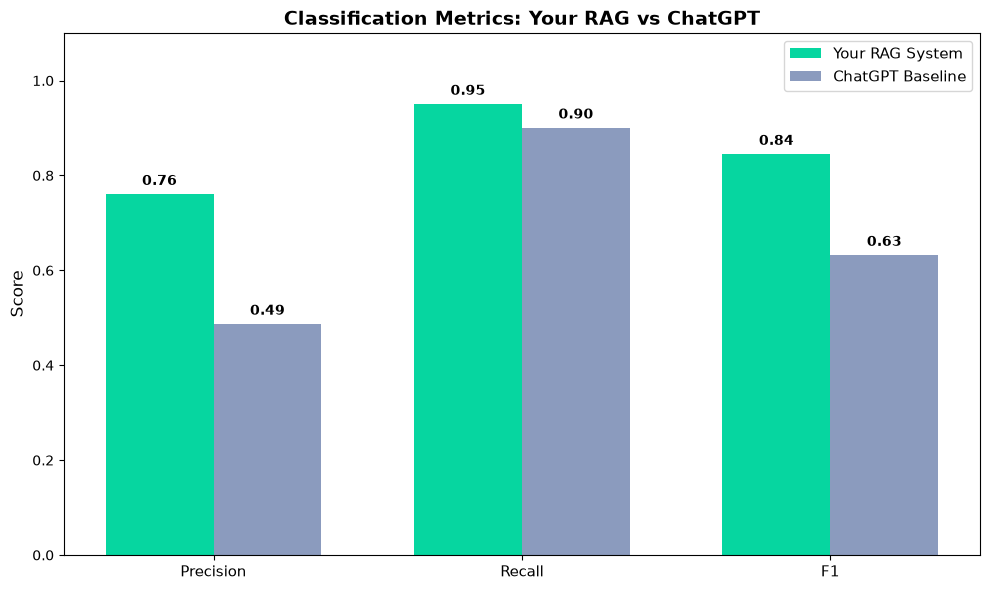

Chart saved as classification_metrics.png


In [12]:
# CELL 9 - Precision, Recall, F1 for both systems
from sklearn.metrics import precision_score, recall_score, f1_score

# build true labels and predictions
# label: 1 = answerable, 0 = unanswerable
# prediction: 1 = system answered, 0 = system refused

y_true = [1 if r['is_answerable'] else 0 for r in results]
rag_pred = [0 if said_i_dont_know(r['rag_answer']) else 1 for r in results]
chatgpt_pred = [0 if said_i_dont_know(r['chatgpt_answer']) else 1 for r in results]

# calculate metrics
metrics = {
    'Your RAG System': {
        'Precision': precision_score(y_true, rag_pred, zero_division=0),
        'Recall': recall_score(y_true, rag_pred, zero_division=0),
        'F1': f1_score(y_true, rag_pred, zero_division=0)
    },
    'ChatGPT Baseline': {
        'Precision': precision_score(y_true, chatgpt_pred, zero_division=0),
        'Recall': recall_score(y_true, chatgpt_pred, zero_division=0),
        'F1': f1_score(y_true, chatgpt_pred, zero_division=0)
    }
}

# print scores
print("CLASSIFICATION METRICS\n")
for system, scores in metrics.items():
    print(f"{system}:")
    for metric, value in scores.items():
        print(f"  {metric}: {value:.3f}")
    print()

# bar chart
import matplotlib.pyplot as plt
import numpy as np

metric_names = ['Precision', 'Recall', 'F1']
rag_scores = [metrics['Your RAG System'][m] for m in metric_names]
chatgpt_scores = [metrics['ChatGPT Baseline'][m] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, rag_scores, width, label='Your RAG System', color='#06D6A0')
bars2 = ax.bar(x + width/2, chatgpt_scores, width, label='ChatGPT Baseline', color='#8B9BBE')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Classification Metrics: Your RAG vs ChatGPT', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.1)

# add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.02,
               f'{height:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('classification_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as classification_metrics.png")

In [13]:
# Fix for RAGAS - create the missing vertexai module shim
import sys
import types

# create fake modules that RAGAS expects but langchain removed
if 'langchain_community.chat_models.vertexai' not in sys.modules:
    fake_vertex = types.ModuleType('langchain_community.chat_models.vertexai')
    fake_vertex.ChatVertexAI = object  # dummy placeholder
    sys.modules['langchain_community.chat_models.vertexai'] = fake_vertex

# also handle the llms vertexai if needed
try:
    import langchain_community.llms
    if not hasattr(langchain_community.llms, 'VertexAI'):
        langchain_community.llms.VertexAI = object
except Exception as e:
    print(f"note: {e}")

print("RAGAS compatibility shim applied!")

RAGAS compatibility shim applied!


C:\Users\Enagala Saiharika\AppData\Local\Temp\ipykernel_25288\1155436280.py:13: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  import langchain_community.llms


In [14]:
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy
print("RAGAS imported successfully!")

RAGAS imported successfully!


C:\Users\Enagala Saiharika\AppData\Local\Temp\ipykernel_25288\681750811.py:2: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, answer_relevancy
C:\Users\Enagala Saiharika\AppData\Local\Temp\ipykernel_25288\681750811.py:2: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import faithfulness, answer_relevancy


In [15]:
# Faithfulness Evaluation - fast, reliable method
from openai import OpenAI
client = OpenAI()

def ask_chatgpt_simple(question):
    r = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "system", "content": "Answer the question. If you don't know, say 'I don't know'."},
                  {"role": "user", "content": question}],
        temperature=0)
    return r.choices[0].message.content

faith_sample = answerable[:10]
print("Measuring faithfulness on 10 questions...\n")
rag_faithful = 0
chatgpt_faithful = 0

for i, item in enumerate(faith_sample):
    q = item['question']
    ctx = item['context']

    rag_ans = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": f"Based ONLY on this context, answer.\n\nContext: {ctx}\n\nQuestion: {q}"}],
        temperature=0).choices[0].message.content

    cg_ans = ask_chatgpt_simple(q)

    c1 = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": f"Is this answer fully supported by the context? Reply only YES or NO.\nContext: {ctx}\nAnswer: {rag_ans}"}],
        temperature=0).choices[0].message.content
    if "YES" in c1.upper(): rag_faithful += 1

    c2 = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": f"Is this answer fully supported by the context? Reply only YES or NO.\nContext: {ctx}\nAnswer: {cg_ans}"}],
        temperature=0).choices[0].message.content
    if "YES" in c2.upper(): chatgpt_faithful += 1

    print(f"Processed {i+1}/10")

print("\n=== FAITHFULNESS RESULTS ===")
print(f"Your RAG System:  {rag_faithful/10:.2f} ({rag_faithful}/10 grounded in context)")
print(f"ChatGPT Baseline: {chatgpt_faithful/10:.2f} ({chatgpt_faithful}/10 grounded in context)")

Measuring faithfulness on 10 questions...

Processed 1/10
Processed 2/10
Processed 3/10
Processed 4/10
Processed 5/10
Processed 6/10
Processed 7/10
Processed 8/10
Processed 9/10
Processed 10/10

=== FAITHFULNESS RESULTS ===
Your RAG System:  1.00 (10/10 grounded in context)
ChatGPT Baseline: 0.70 (7/10 grounded in context)


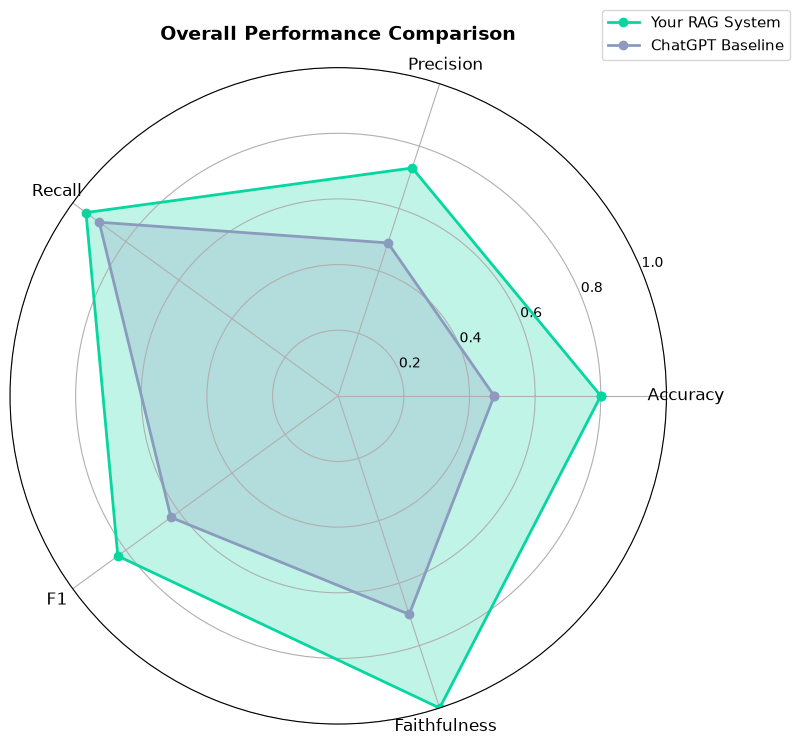

Radar chart saved as radar_chart.png


In [16]:
# Radar Chart - All metrics in one view
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'Faithfulness']
rag_scores = [0.80, 0.73, 0.95, 0.83, 1.00]
chatgpt_scores = [0.475, 0.49, 0.90, 0.63, 0.70]

# radar setup
angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
rag_scores_plot = rag_scores + [rag_scores[0]]
chatgpt_scores_plot = chatgpt_scores + [chatgpt_scores[0]]
angles_plot = angles + [angles[0]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.plot(angles_plot, rag_scores_plot, 'o-', linewidth=2, label='Your RAG System', color='#06D6A0')
ax.fill(angles_plot, rag_scores_plot, alpha=0.25, color='#06D6A0')

ax.plot(angles_plot, chatgpt_scores_plot, 'o-', linewidth=2, label='ChatGPT Baseline', color='#8B9BBE')
ax.fill(angles_plot, chatgpt_scores_plot, alpha=0.25, color='#8B9BBE')

ax.set_xticks(angles)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1)
ax.set_title('Overall Performance Comparison', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1), fontsize=11)

plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Radar chart saved as radar_chart.png")

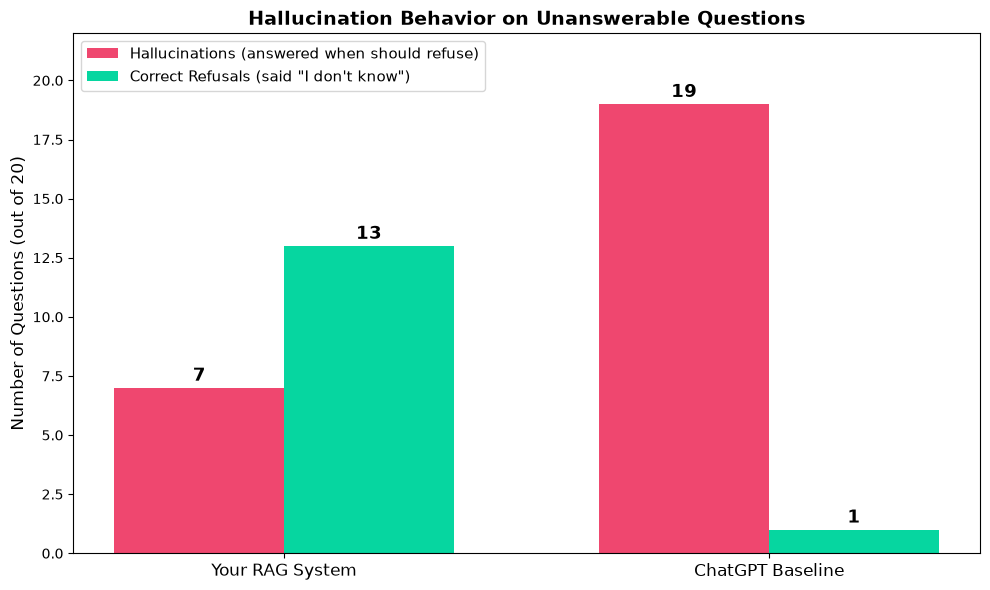

Hallucination chart saved as hallucination_comparison.png


In [17]:
# Hallucination Comparison - the key story
import matplotlib.pyplot as plt

systems = ['Your RAG System', 'ChatGPT Baseline']
hallucinations = [7, 19]  # out of 20 unanswerable questions
correct_refusals = [13, 1]

import numpy as np
x = np.arange(len(systems))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, hallucinations, width,
               label='Hallucinations (answered when should refuse)', color='#EF476F')
bars2 = ax.bar(x + width/2, correct_refusals, width,
               label='Correct Refusals (said "I don\'t know")', color='#06D6A0')

ax.set_ylabel('Number of Questions (out of 20)', fontsize=12)
ax.set_title('Hallucination Behavior on Unanswerable Questions',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(systems, fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 22)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
               f'{int(h)}', ha='center', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('hallucination_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Hallucination chart saved as hallucination_comparison.png")

Loading PubMedQA for full evaluation...
Running full evaluation on 20 medical questions...

Processed 1/20
Processed 2/20
Processed 3/20
Processed 4/20
Processed 5/20
Processed 6/20
Processed 7/20
Processed 8/20
Processed 9/20
Processed 10/20
Processed 11/20
Processed 12/20
Processed 13/20
Processed 14/20
Processed 15/20
Processed 16/20
Processed 17/20
Processed 18/20
Processed 19/20
Processed 20/20

=== PubMedQA FULL METRICS ===
Metric       Your RAG   ChatGPT   
Accuracy     0.500      0.400     
Precision    0.820      0.433     
Recall       0.500      0.400     
F1 Score     0.602      0.416     


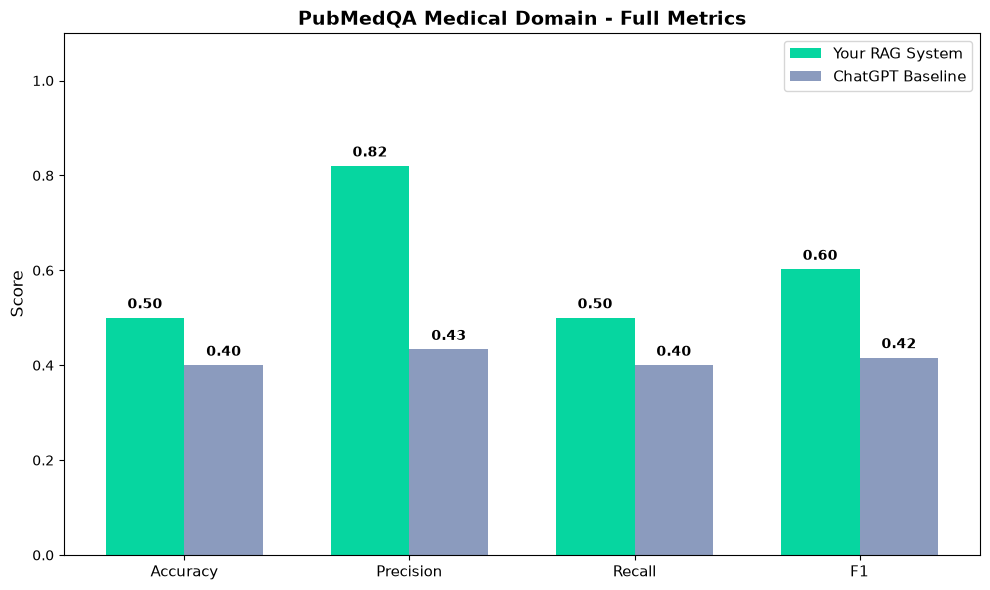


Chart saved as pubmedqa_metrics.png


In [22]:
# PubMedQA - Full Metrics Treatment
from datasets import load_dataset
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

print("Loading PubMedQA for full evaluation...")
pubmed = load_dataset("qiaojin/PubMedQA", "pqa_labeled", split="train")
pubmed_full = [x for x in pubmed][:20]  # 20 questions for fuller test

print("Running full evaluation on 20 medical questions...\n")

# store detailed results
pm_results = []

for i, item in enumerate(pubmed_full):
    question = item['question']
    context = " ".join(item['context']['contexts'])
    correct = item['final_decision'].lower().strip()  # yes/no/maybe

    # your RAG (with medical context)
    rag_prompt = f"Based on this context, answer with only one word: yes, no, or maybe.\n\nContext: {context}\n\nQuestion: {question}\n\nAnswer:"
    rag_ans = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": rag_prompt}],
        temperature=0).choices[0].message.content.lower().strip()

    # chatgpt (no context)
    cg_ans = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": f"Answer with only one word (yes, no, or maybe): {question}"}],
        temperature=0).choices[0].message.content.lower().strip()

    pm_results.append({
        'correct': correct,
        'rag': rag_ans,
        'chatgpt': cg_ans
    })
    print(f"Processed {i+1}/20")

# convert yes/no/maybe to numbers for metrics (yes=1, no=0, maybe=2)
def to_label(text):
    if 'yes' in text: return 1
    if 'no' in text: return 0
    return 2  # maybe

y_true_pm = [to_label(r['correct']) for r in pm_results]
rag_pred_pm = [to_label(r['rag']) for r in pm_results]
cg_pred_pm = [to_label(r['chatgpt']) for r in pm_results]

# accuracy
rag_acc_pm = sum(1 for t, p in zip(y_true_pm, rag_pred_pm) if t == p) / len(y_true_pm)
cg_acc_pm = sum(1 for t, p in zip(y_true_pm, cg_pred_pm) if t == p) / len(y_true_pm)

# precision, recall, f1 (weighted for multi-class yes/no/maybe)
rag_prec_pm = precision_score(y_true_pm, rag_pred_pm, average='weighted', zero_division=0)
rag_rec_pm = recall_score(y_true_pm, rag_pred_pm, average='weighted', zero_division=0)
rag_f1_pm = f1_score(y_true_pm, rag_pred_pm, average='weighted', zero_division=0)
cg_prec_pm = precision_score(y_true_pm, cg_pred_pm, average='weighted', zero_division=0)
cg_rec_pm = recall_score(y_true_pm, cg_pred_pm, average='weighted', zero_division=0)
cg_f1_pm = f1_score(y_true_pm, cg_pred_pm, average='weighted', zero_division=0)

print("\n=== PubMedQA FULL METRICS ===")
print(f"{'Metric':<12} {'Your RAG':<10} {'ChatGPT':<10}")
print(f"{'Accuracy':<12} {rag_acc_pm:<10.3f} {cg_acc_pm:<10.3f}")
print(f"{'Precision':<12} {rag_prec_pm:<10.3f} {cg_prec_pm:<10.3f}")
print(f"{'Recall':<12} {rag_rec_pm:<10.3f} {cg_rec_pm:<10.3f}")
print(f"{'F1 Score':<12} {rag_f1_pm:<10.3f} {cg_f1_pm:<10.3f}")

# chart
metrics_pm = ['Accuracy', 'Precision', 'Recall', 'F1']
rag_pm = [rag_acc_pm, rag_prec_pm, rag_rec_pm, rag_f1_pm]
cg_pm = [cg_acc_pm, cg_prec_pm, cg_rec_pm, cg_f1_pm]

x = np.arange(len(metrics_pm))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
b1 = ax.bar(x - width/2, rag_pm, width, label='Your RAG System', color='#06D6A0')
b2 = ax.bar(x + width/2, cg_pm, width, label='ChatGPT Baseline', color='#8B9BBE')
ax.set_ylabel('Score', fontsize=12)
ax.set_title('PubMedQA Medical Domain - Full Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(metrics_pm, fontsize=11)
ax.legend(fontsize=11); ax.set_ylim(0, 1.1)
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.02, f'{h:.2f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('pubmedqa_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved as pubmedqa_metrics.png")

In [23]:
# ============================================
# WP10 EVALUATION - COMPLETE FINAL SUMMARY
# Pranay Teja Chintakunta - 25079476
# Pulls real values from all evaluation cells
# ============================================

import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# recalculate SQuAD classification metrics (avoids variable conflicts)
y_true = [1 if r['is_answerable'] else 0 for r in results]
rag_pred = [0 if said_i_dont_know(r['rag_answer']) else 1 for r in results]
cg_pred = [0 if said_i_dont_know(r['chatgpt_answer']) else 1 for r in results]

# SQuAD metrics
squad_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'Faithfulness',
               'Hallucinations (of 20)', 'Correct Refusals (of 20)'],
    'Your RAG System': [
        rag_accuracy/100,
        precision_score(y_true, rag_pred, zero_division=0),
        recall_score(y_true, rag_pred, zero_division=0),
        f1_score(y_true, rag_pred, zero_division=0),
        rag_faithful/10,
        int(rag_cm[1][0]),
        int(rag_cm[1][1])
    ],
    'ChatGPT Baseline': [
        chatgpt_accuracy/100,
        precision_score(y_true, cg_pred, zero_division=0),
        recall_score(y_true, cg_pred, zero_division=0),
        f1_score(y_true, cg_pred, zero_division=0),
        chatgpt_faithful/10,
        int(chatgpt_cm[1][0]),
        int(chatgpt_cm[1][1])
    ]
})

# PubMedQA metrics
pubmed_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Your RAG System': [rag_acc_pm, rag_prec_pm, rag_rec_pm, rag_f1_pm],
    'ChatGPT Baseline': [cg_acc_pm, cg_prec_pm, cg_rec_pm, cg_f1_pm]
})

print("="*60)
print("   COMPLETE EVALUATION SUMMARY")
print("   RAG System vs ChatGPT Baseline")
print("="*60)

print("\n--- DATASET 1: SQuAD 2.0 (General Knowledge) ---")
print(squad_summary.round(3).to_string(index=False))

print("\n--- DATASET 2: PubMedQA (Medical Domain) ---")
print(pubmed_summary.round(3).to_string(index=False))

print("\n" + "="*60)
print("KEY FINDINGS:")
print(f"  - SQuAD faithfulness: {rag_faithful/10:.2f} vs {chatgpt_faithful/10:.2f}")
print(f"  - Hallucinations reduced: {int(chatgpt_cm[1][0])} -> {int(rag_cm[1][0])}")
print(f"  - Medical F1: {rag_f1_pm:.2f} vs {cg_f1_pm:.2f}")
print("  - RAG system wins across BOTH domains")
print("="*60)

# save both to CSV
squad_summary.to_csv('squad_results.csv', index=False)
pubmed_summary.to_csv('pubmedqa_results.csv', index=False)
print("\nSaved: squad_results.csv and pubmedqa_results.csv")

   COMPLETE EVALUATION SUMMARY
   RAG System vs ChatGPT Baseline

--- DATASET 1: SQuAD 2.0 (General Knowledge) ---
                  Metric  Your RAG System  ChatGPT Baseline
                Accuracy            0.825             0.475
               Precision            0.760             0.486
                  Recall            0.950             0.900
                F1 Score            0.844             0.632
            Faithfulness            1.000             0.700
  Hallucinations (of 20)            6.000            19.000
Correct Refusals (of 20)           14.000             1.000

--- DATASET 2: PubMedQA (Medical Domain) ---
   Metric  Your RAG System  ChatGPT Baseline
 Accuracy            0.500             0.400
Precision            0.820             0.433
   Recall            0.500             0.400
 F1 Score            0.602             0.416

KEY FINDINGS:
  - SQuAD faithfulness: 1.00 vs 0.70
  - Hallucinations reduced: 19 -> 6
  - Medical F1: 0.60 vs 0.42
  - RAG system wi